# Bat Echolocation Feature Extraction
Goal: Extract features from bat echolocation calls, remove outliers, then average across all calls in a bat pass

--> Program is semi-automated, so you run cells at the top and then add filename and adjust thresholds until the calls are correctly highlighted using the waveform/spectrogram, then run the rest of the program and it will export your results in a csv.

Steps:
1. Input a file
2. Apply high-pass filter to remove lower-frequency background noise below the bat calls. Low-pass filter optional if needed.
3. Normalize amplitude
4. Visualize
5. Use voice activity detection (VAD) with energy cutoff to get the timestamps for the bat calls and inter-call intervals (ICIs)
6. For each call within the bat pass (excluding first and last which could be cut off), extract the following features:
    - start time
    - end time
    - call duration
    - time until the next call
    - min frequency
    - max frequency
    - frequency of most energy
    - slope estimate assuming downward shape
7. Show those results in a table, with each column being a feature, and each row being a call
8. Check for outliers on each feature and remove calls with outliers
9. Check for presence of feeding buzzes, and extract the duration and min_freq in the feeding buzz
10. Get averages for the features and prep for export

Example bat pass used was recorded by K Rubio in Medford, Massachusetts at Upper Mystic Lake on Sept 14, 2025

Author: K Rubio

Last modified: 4/30/2026

In [3]:
import librosa
import librosa.display
from vad import EnergyVAD # https://pypi.org/project/energy-vad/
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import zscore
import os
import sys
from pathlib import Path

In [4]:
# have to modify where notebook looks for imports so it looks in the project root, not the notebook folder
os.getcwd()
sys.path.append(str(Path().resolve().parent))
print(sys.path)

['/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python312.zip', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12/lib-dynload', '', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/Data_Science/Audio Signal Processing/Potential Projects/2026_Audio_Signal_Analysis/audio-signal-analysis/.venv/lib/python3.12/site-packages', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/Data_Science/Audio Signal Processing/Potential Projects/2026_Audio_Signal_Analysis/audio-signal-analysis']


In [ ]:
from utils.time_domain_utils import (
  plot_waveform,
  rms_normalize,
  get_voice_activity_timestamps,
  get_timestamps_silences,
)
from utils.frequency_domain_utils import (
  plot_spectrogram,
  ideal_frequency_filter,
  extract_min_max_and_most_energy_frequencies
)

## File input and Thresholds to adjust

In [28]:
filename = 'bat_20250914_2053.wav'
filepath = f'../data/audio/{filename}'
sr = 384000
# High pass filter cutoff to zero out frequencies below bat sounds --> adjust after checking spectrogram
CUTOFF = 36000 # Hz

# Spectrogram visualization settings
SPECTROGRAM_MIN_FREQ = CUTOFF
SPECTROGRAM_MAX_FREQ = 100000

# VAD Settings --> adjust these depending on how fast the bat is making sounds
FRAME_LENGTH = 5 # milliseconds
FRAME_SHIFT = 2 # milliseconds
# Generally a silence longer than 90ms is should separate one search call from another
MIN_ICI = 20 # in milliseconds
# call might be 19ms (3-50ms) or 0.5ms for micro-calls, while a ICI might be like 228ms
# Search phase ICI's are ~100 ms or longer
# Approach phase ICI's are ~20 ms
# Feeding buzz ICI's are ~9-18 ms

In [29]:
# Load audio with Librosa.load and sample at the correct rate
file, _ = librosa.load(filepath, sr=sr)
# Apply the Short-Time Fourier Transform to convert to the frequency domain
FRAME_LENGTH_SPEC = 2048
HOP_LENGTH_SPEC = FRAME_LENGTH_SPEC//4
stft_bat = librosa.stft(file, n_fft=FRAME_LENGTH_SPEC, hop_length=HOP_LENGTH_SPEC)
stft_bat.shape
stft_bat_abs = np.abs(stft_bat) ** 2

In [10]:
# Apply High Pass Filter


# Apply high ideal pass frequency that will filter zero's out all frequencies below a cutoff
result = ideal_frequency_filter(stft_bat, sr, FRAME_LENGTH_SPEC, CUTOFF, 'high')

bat_frequencies = result['frequencies']
stft_filtered = result['stft_filtered']
stft_bat_filtered_abs = result['stft_filtered_abs']
stft_filtered_dB = result['stft_filtered_dB']
# Convert back to the time domain using the inverse STFT
bat_filtered = librosa.istft(stft_filtered, hop_length=HOP_LENGTH_SPEC)

In [9]:
# Normalize audio signal so amplitude/volume is consistent across files using root mean square energy
bat_filtered_normalized = rms_normalize(bat_filtered, target_dBFS=-30.0)
stft_bat = librosa.stft(bat_filtered_normalized, n_fft=FRAME_LENGTH_SPEC, hop_length=HOP_LENGTH_SPEC)
stft_bat_filtered_abs = np.abs(stft_bat) ** 2
stft_bat_filtered_dB = librosa.power_to_db(np.abs(stft_bat_filtered_abs), ref=np.max)

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Bat'}, xlabel='Time (sec)', ylabel='Amplitude'>)

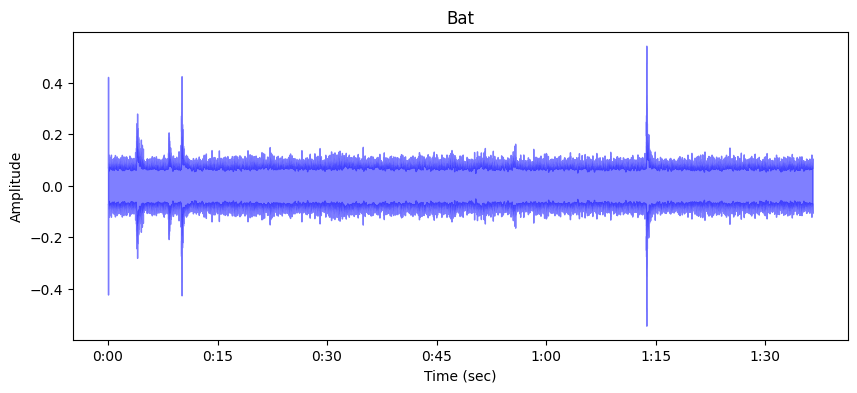

In [12]:
# Plot waveform
plot_waveform(bat_filtered_normalized, 'Bat')

(<Figure size 2500x400 with 1 Axes>,
 <Axes: title={'center': 'Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>)

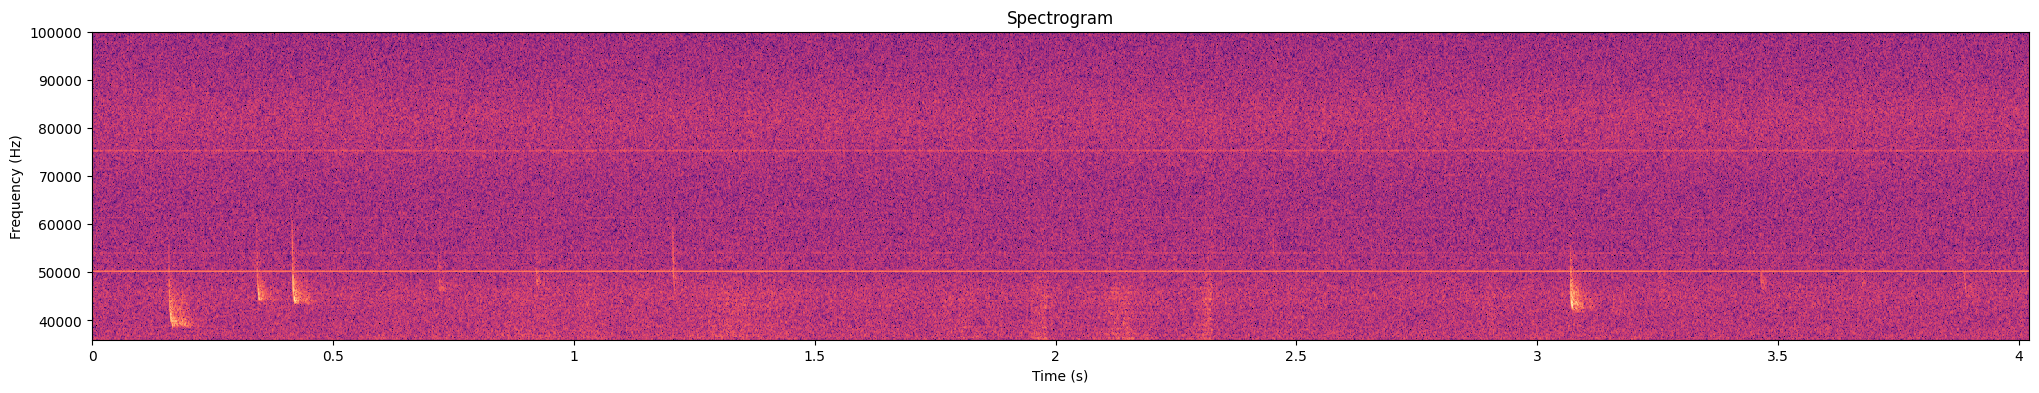

In [13]:
# Plot spectrogram
plot_spectrogram(
    stft_bat_filtered_dB,
    sr,
    HOP_LENGTH_SPEC,
    "linear",
    SPECTROGRAM_MIN_FREQ,
    SPECTROGRAM_MAX_FREQ)

(<Figure size 2500x400 with 1 Axes>,
 <Axes: title={'center': 'Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>)

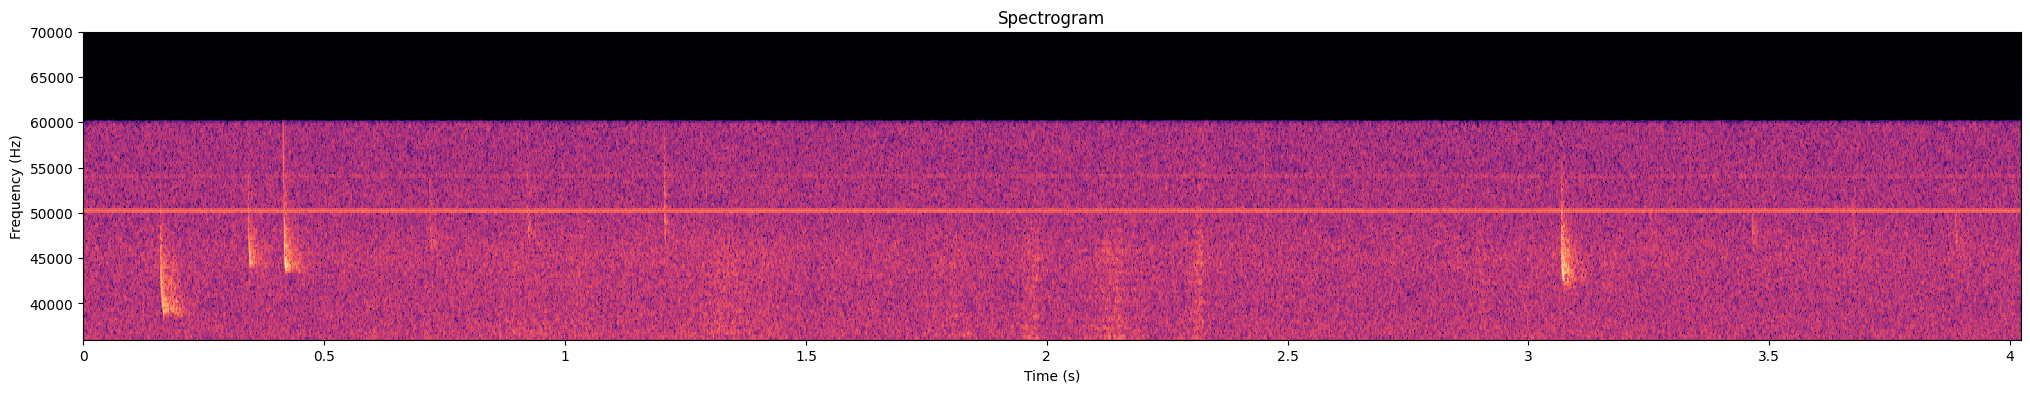

In [14]:
# OPTIONAL Low Pass Filter - Filter out higher frequencies

HIGH_CUTOFF = 60000
cutoff_idx_high = np.argmax(bat_frequencies >= HIGH_CUTOFF)
stft_bat_filtered = stft_filtered.copy()
stft_bat_filtered[cutoff_idx_high:, :] = 0
stft_bat_filtered_abs = np.abs(stft_bat_filtered) ** 2
bat_filtered = librosa.istft(stft_bat_filtered, hop_length=HOP_LENGTH_SPEC)

# Normalize audio signal so amplitude/volume is consistent across files using root mean square energy
bat_filtered_normalized = rms_normalize(bat_filtered, target_dBFS=-30.0)
stft_bat = librosa.stft(bat_filtered_normalized, n_fft=FRAME_LENGTH_SPEC, hop_length=HOP_LENGTH_SPEC)
stft_bat_filtered_abs = np.abs(stft_bat) ** 2
stft_bat_filtered_dB = librosa.power_to_db(np.abs(stft_bat_filtered_abs), ref=np.max)

# Plot spectrogram
plot_spectrogram(
    stft_bat_filtered_dB,
    sr,
    HOP_LENGTH_SPEC,
    "linear",
    SPECTROGRAM_MIN_FREQ,
    HIGH_CUTOFF+ 10000)

In [15]:
# !!! Help picking an energy threshold
# fill out the number of expected calls you'd expect to see based on the waveform and
# spectrogram that are LOUDER than wind. Include non-call sounds that are as 
# loud as the calls and above the frequency cutoff --> these will be removed later 
# if they're outliers
NUM_OF_CALLS = 4

In [16]:
# Automated choosing energy threshold based on user estimate of
# number of calls, using lowest possible energy threshold that gets
# close to that number.
# Goal is for the program to correctly highlight the calls below
energy_threshold = 0.01
num_of_calls = 0
max_runs = 1000
run = 0

while num_of_calls < NUM_OF_CALLS - 1 and run < max_runs:
    
    # energy_threshold += 0.01
    energy_threshold = energy_threshold + 0.01
    vad = EnergyVAD(
        frame_length=FRAME_LENGTH,
        frame_shift=FRAME_SHIFT,
        sample_rate=sr,
        energy_threshold=energy_threshold)
    vad_output = vad(bat_filtered_normalized)
    # Get timestamps for calls
    calls = get_voice_activity_timestamps(
        vad_output=vad_output,
        frame_shift=FRAME_SHIFT,
        min_silence_duration=MIN_ICI)
    num_of_calls = len(calls)
    run += 1
print(f'Energy threshold should be at least: {energy_threshold:2f} identified {len(calls)} calls but raise as needed')
ENERGY_THRESHOLD = energy_threshold

Energy threshold should be at least: 0.620000 identified 4 calls but raise as needed


In [17]:
# re-adjust energy threshold as needed to make sure waveform below makes sense
ENERGY_THRESHOLD = 2

In [18]:
# VAD
vad = EnergyVAD(
    frame_length=FRAME_LENGTH,
    frame_shift=FRAME_SHIFT,
    sample_rate=sr,
    energy_threshold=ENERGY_THRESHOLD)
vad_output = vad(bat_filtered_normalized)
# Get timestamps for calls
calls = get_voice_activity_timestamps(vad_output=vad_output, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_ICI)

# Get timestamps for silences between calls
icis = get_timestamps_silences(vad_output=vad_output, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_ICI)
# If the first ICI starts at 0, cut it off since we don't want that at the beginning
if len(icis) > 0 and icis[0]['start'] == 0:
    icis = icis[1:]
print(f'Identified {len(calls)} call(s) and {len(icis)} silences')
if len(calls) < 4:
    print('Error! This is not enough calls. Try increasing the ENERGY_THRESHOLD')

Identified 5 call(s) and 5 silences


(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Bat'}, xlabel='Time (sec)', ylabel='Amplitude'>)

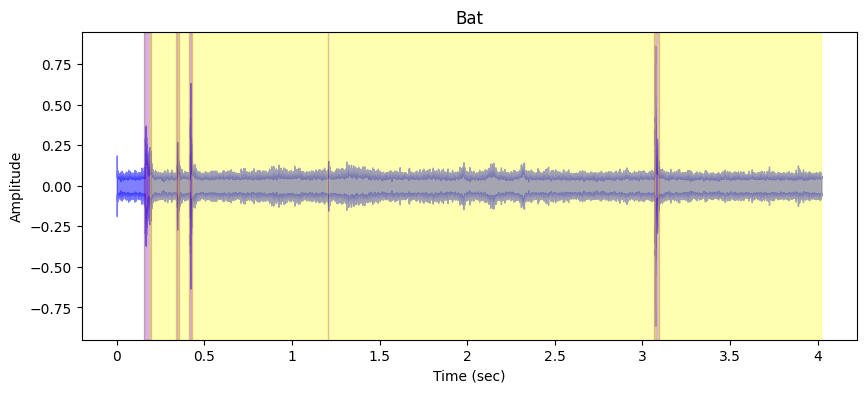

In [19]:
plot_waveform(bat_filtered_normalized, 'Bat', sr, calls, icis)

In [20]:
# If there are more calls than ICI's, cut the last call out
if len(calls) > len(icis):
    calls = calls[:-1]

In [21]:
# Extract time data
starts = []
ends = []
durations_ms = []
for call in calls:
    starts.append(call['start'])
    ends.append(call['end'])
    durations_ms.append((call['end'] - call['start']) * 1000)
start_end_data = {'start': starts, 'end': ends, 'duration_ms': durations_ms}
df = pd.DataFrame(start_end_data)
# Add time_to_next_call_ms to the dataframe
time_to_next_call_ms = []
for ici in icis:
    time_to_next_call_ms.append((ici['end'] - ici['start']) * 1000)
df['time_to_next_call_ms'] = time_to_next_call_ms

In [24]:
# Frequency domain data
times = librosa.frames_to_time(np.arange(stft_bat_filtered_abs.shape[1]),
                               sr=sr,
                               hop_length=HOP_LENGTH_SPEC)
frequency_data = []
for call in calls:
    energy_cutoff = 0.04
    call_data = extract_min_max_and_most_energy_frequencies(
        stft_bat_filtered_abs,
        times,
        call['start'],
        call['end'],
        energy_cutoff,
        bat_frequencies)
    frequency_data.append(call_data)
# Add these as columns to the data frame
min_freqs = []
max_freqs = []
max_energy_freqs = []
for row in frequency_data:
    min_freqs.append(row['min_freq'])
    max_freqs.append(row['max_freq'])
    max_energy_freqs.append(row['max_energy_freq'])
df['min_freq'] = min_freqs
df['max_freq'] = max_freqs  
df['max_energy_freq'] = max_energy_freqs
# Calculate simple slopes for all calls and add to table
df['slope'] = (df['min_freq'] - df['max_freq']) / ((df['end'] - df['start']) * 1000)

In [23]:
# Check df
df

,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
0,0.156,0.194,38.0,150.0,38812.5,50437.5,39750.0,-305.921053
1,0.340,0.354,14.0,60.0,44062.5,50437.5,44437.5,-455.357143
2,0.412,0.432,20.0,770.0,43687.5,50250.0,44250.0,-328.125000
3,1.204,1.208,4.0,1860.0,36187.5,58875.0,50250.0,-5671.875000
4,3.066,3.092,26.0,930.0,42375.0,50250.0,43687.5,-302.884615


## Data cleaning

In [25]:
# OPTIONAL - Drop first and last row, as first and last call may be cut off, and/or have 
# innacurate time_to_next_call
# df2 = df.iloc[1:-1]
df2 = df

In [26]:
# drop outliers
# Look at duration outliers, first create a copy of the original data frame (to preserve original indexing)
df_zscores = df2.copy()
df_zscores.drop(['duration_ms', 'time_to_next_call_ms', 'min_freq', 'max_freq', 'max_energy_freq', 'slope'], axis=1, inplace=True)
df_zscores['duration_ms'] = zscore(df2['duration_ms'])
df_zscores['time_to_next_call_ms'] = zscore(df2['time_to_next_call_ms'])
df_zscores['min_freq'] = zscore(df2['min_freq'])
df_zscores['max_freq'] = zscore(df2['max_freq'])
df_zscores['max_energy_freq'] = zscore(df2['max_energy_freq'])
df_zscores['slope'] = zscore(df2['slope'])

duration_outliers = df_zscores[abs(df_zscores['duration_ms']) > 3].index.tolist()
time_to_next_call_ms_outliers = df_zscores[abs(df_zscores['time_to_next_call_ms']) > 3].index.tolist()
min_freq_outliers = df_zscores[abs(df_zscores['min_freq']) > 3].index.tolist()
max_freq_outliers = df_zscores[abs(df_zscores['max_freq']) > 3].index.tolist()
max_energy_freq_outliers = df_zscores[abs(df_zscores['max_energy_freq']) > 3].index.tolist()
slope_outliers = df_zscores[abs(df_zscores['slope']) > 3].index.tolist()

df3 = df2.copy()
for outlier in duration_outliers:
    df3.loc[outlier, 'duration_ms'] = np.nan
for outlier in time_to_next_call_ms_outliers:
    df3.loc[outlier, 'time_to_next_call_ms'] = np.nan
for outlier in min_freq_outliers:
    df3.loc[outlier, 'min_freq'] = np.nan
for outlier in max_freq_outliers:
    df3.loc[outlier, 'max_freq'] = np.nan
for outlier in max_energy_freq_outliers:
    df3.loc[outlier, 'max_energy_freq'] = np.nan
for outlier in slope_outliers:
    df3.loc[outlier, 'slope'] = np.nan
df3

,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
0,0.156,0.194,38.0,150.0,38812.5,50437.5,39750.0,-305.921053
1,0.340,0.354,14.0,60.0,44062.5,50437.5,44437.5,-455.357143
2,0.412,0.432,20.0,770.0,43687.5,50250.0,44250.0,-328.125000
3,1.204,1.208,4.0,1860.0,36187.5,58875.0,50250.0,-5671.875000
4,3.066,3.092,26.0,930.0,42375.0,50250.0,43687.5,-302.884615


In [30]:
# Final statistics on the bat pass
# Generate key features from this bat pass and save in a dictionary
avg_duration_ms = df3['duration_ms'].mean()
avg_ici = df3['time_to_next_call_ms'].mean()
avg_min_freq = df3['min_freq'].mean() / 1000
avg_max_freq = df3['max_freq'].mean() / 1000
avg_freq_of_most_energy = df3['max_energy_freq'].mean() / 1000
avg_slope = df3['slope'].mean()
bat_pass_features = {
    'filename': filename,
    'duration_ms': avg_duration_ms,
    'ici_ms': avg_ici,
    'min_freq': avg_min_freq,
    'max_freq': avg_max_freq,
    'freq_of_most_energy': avg_freq_of_most_energy,
    'slope': avg_slope,
}
print(f' Bat pass features: {filename}')
print(f'Number of calls {len(calls)}')
print(f'Average call duration: {avg_duration_ms:.2f} ms')
print(f'Average ICI: {avg_ici:.2f} ms')
print(f'Average min frequency: {avg_min_freq:.2f} kHz')
print(f'Average max frequency: {avg_max_freq:.2f} kHz')
print(f'Average frequency with most energy: {avg_freq_of_most_energy:.2f} kHz')
print(f'Average call slope: {avg_slope:.2f} Hz/ms')


 Bat pass features: bat_20250914_2053.wav
Number of calls 5
Average call duration: 20.40 ms
Average ICI: 754.00 ms
Average min frequency: 41.02 kHz
Average max frequency: 52.05 kHz
Average frequency with most energy: 44.48 kHz
Average call slope: -1412.83 Hz/ms


In [ ]:
# Export results to csv
columns=['filename','duration_ms','ici_ms','min_freq','max_freq','freq_of_most_energy','slope']
results = pd.DataFrame([bat_pass_features], columns=columns)
results.to_csv("data/output/output.csv", mode="a", header=False, index=False)